# Discriminant Analysis & Naive Bayes
**Jennifer Eigo - University of Connecticut - Dept. of Operations and Information Management**

-------------------------------------
These two models are just used for classification - they cannot predict a continuous target.  DA uses distance measures to decide what existing class is most similar to the new instance to be classified.  It kind of builds on the work we did in cluster analysis, except now we have labeled data where a class is already known in the training data.  Naive bayes is unique in that it only uses categorical predictors in its simplest form.  (We can run the gaussian version of the model to use continuous predictors.) The logic is all based on combined probabilities of categories.  This model is good for working with survey data which is often categorical.  


# Environment Setup

In [1]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm


In [2]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load the Data - Universal Bank

To practice decision trees, we need a dataset that has a categorical target.  The Universal Bank dataset can be used to predict if a customer will accept an offer of a personal loan.  Each row represents a bank customer and the target variable is called Personal Loan.

In [3]:
# read data
# on the lefthand side, navigate to your data and copy the path
df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M9/UniversalBank.csv')

In [4]:
# shape
# shows how many rows and columns
# this sample has 5000 rows and 14 columns
df.shape

(5000, 14)

In [5]:
# Preview
print(df.head())

   ID Personal Loan  Age  Experience  Income  ZIP Code  Family  CCAvg  \
0   1            No   25           1      49     91107       4    1.6   
1   2            No   45          19      34     90089       3    1.5   
2   3            No   39          15      11     94720       1    1.0   
3   4            No   35           9     100     94112       1    2.7   
4   5            No   35           8      45     91330       4    1.0   

   Education  Mortgage  Securities Account  CD Account  Online  CreditCard  
0  Undergrad         0                   1           0       0           0  
1  Undergrad         0                   1           0       0           0  
2  Undergrad         0                   0           0       0           0  
3   Graduate         0                   0           0       0           0  
4   Graduate         0                   0           0       0           1  


In [6]:
# list the columns with the data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Personal Loan       5000 non-null   object 
 2   Age                 5000 non-null   int64  
 3   Experience          5000 non-null   int64  
 4   Income              5000 non-null   int64  
 5   ZIP Code            5000 non-null   int64  
 6   Family              5000 non-null   int64  
 7   CCAvg               5000 non-null   float64
 8   Education           5000 non-null   object 
 9   Mortgage            5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 547.0+ KB
None


Looks like a mix of categorical and continuous predictors.  We should  change our target variable to 1s and 0s.  And let's make dummy variables for Education.  We should drop Zip Code because it has too many categories.  

In [7]:
# Convert 'Personal Loan' to numerical (Yes=1, No=0) using map
df['Personal Loan'] = df['Personal Loan'].map({'Yes': 1, 'No': 0})

# Display the first few rows and unique values to see the changes in the target variable
print(df.head())
print("\nUnique values after conversion:")
print(df['Personal Loan'].unique())

   ID  Personal Loan  Age  Experience  Income  ZIP Code  Family  CCAvg  \
0   1              0   25           1      49     91107       4    1.6   
1   2              0   45          19      34     90089       3    1.5   
2   3              0   39          15      11     94720       1    1.0   
3   4              0   35           9     100     94112       1    2.7   
4   5              0   35           8      45     91330       4    1.0   

   Education  Mortgage  Securities Account  CD Account  Online  CreditCard  
0  Undergrad         0                   1           0       0           0  
1  Undergrad         0                   1           0       0           0  
2  Undergrad         0                   0           0       0           0  
3   Graduate         0                   0           0       0           0  
4   Graduate         0                   0           0       0           1  

Unique values after conversion:
[0 1]


In [8]:
# Look at counts of 0 and 1 values for Personal Loan to check our work
personal_loan_counts = df['Personal Loan'].value_counts()
print("Counts of Personal Loan (0s and 1s):")
print(personal_loan_counts)

Counts of Personal Loan (0s and 1s):
Personal Loan
0    4520
1     480
Name: count, dtype: int64


In [9]:
# Drop the 'ZIP Code' column
df = df.drop('ZIP Code', axis=1)

In [10]:
# Create dummy variables for 'Education'
df = pd.get_dummies(df, columns=['Education'], drop_first=True)

# Display the first few rows to see the changes
print(df.head())

   ID  Personal Loan  Age  Experience  Income  Family  CCAvg  Mortgage  \
0   1              0   25           1      49       4    1.6         0   
1   2              0   45          19      34       3    1.5         0   
2   3              0   39          15      11       1    1.0         0   
3   4              0   35           9     100       1    2.7         0   
4   5              0   35           8      45       4    1.0         0   

   Securities Account  CD Account  Online  CreditCard  Education_Professional  \
0                   1           0       0           0                   False   
1                   1           0       0           0                   False   
2                   0           0       0           0                   False   
3                   0           0       0           0                   False   
4                   0           0       0           1                   False   

   Education_Undergrad  
0                 True  
1                 

Now let's partition the data to get it ready for modeling. We define Personal Loan as the target variable and the rest of the columns as our predictor variables.  We will do a 50/30/20 split.  In the code we first separate out the 20% for test, then we split the remaining portion into training and validation.

In [11]:
from sklearn.model_selection import train_test_split

# Define the target variable
target = 'Personal Loan'
# Define features by dropping the target variable and the 'ID' column
features = df.drop([target, 'ID'], axis=1)
target_variable = df[target]

# Split the data into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(features, target_variable, test_size=0.2, random_state=42)

# Split the 80% training data into 50% training and 30% validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.375, random_state=42) # 0.375 * 0.8 = 0.3

# Print the shapes of the resulting datasets
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (2500, 12) (2500,)
Validation set shape: (1500, 12) (1500,)
Test set shape: (1000, 12) (1000,)


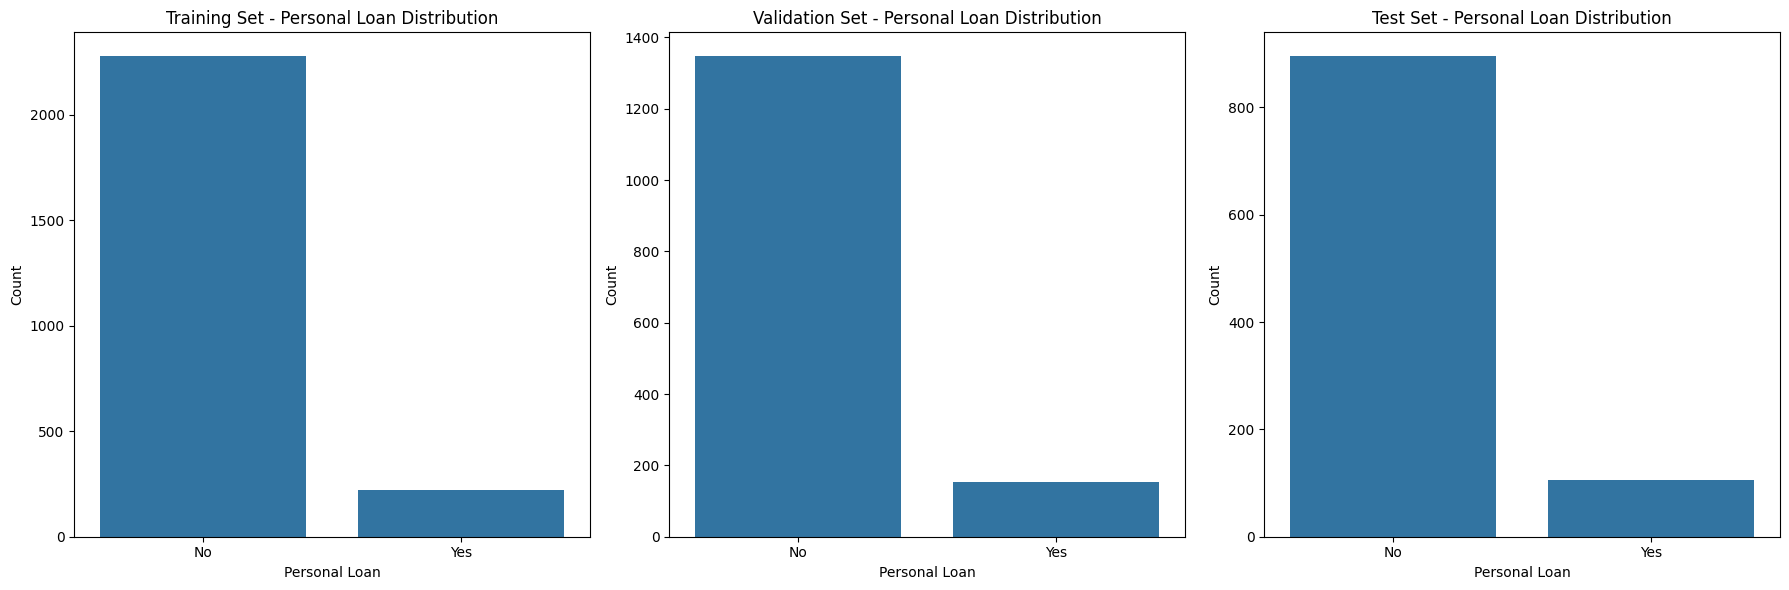

Training set Personal Loan counts and percentages:
Personal Loan
0    2278
1     222
Name: count, dtype: int64
Personal Loan
0    91.12
1     8.88
Name: proportion, dtype: float64

Validation set Personal Loan counts and percentages:
Personal Loan
0    1347
1     153
Name: count, dtype: int64
Personal Loan
0    89.8
1    10.2
Name: proportion, dtype: float64

Test set Personal Loan counts and percentages:
Personal Loan
0    895
1    105
Name: count, dtype: int64
Personal Loan
0    89.5
1    10.5
Name: proportion, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the features and target for plotting
train_data = X_train.copy()
train_data['Personal Loan'] = y_train

val_data = X_val.copy()
val_data['Personal Loan'] = y_val

test_data = X_test.copy()
test_data['Personal Loan'] = y_test

# Plot the distribution of 'Personal Loan' in each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=train_data, x='Personal Loan', ax=axs[0])
axs[0].set_title('Training Set - Personal Loan Distribution')
axs[0].set_xlabel('Personal Loan')
axs[0].set_ylabel('Count')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No', 'Yes'])

sns.countplot(data=val_data, x='Personal Loan', ax=axs[1])
axs[1].set_title('Validation Set - Personal Loan Distribution')
axs[1].set_xlabel('Personal Loan')
axs[1].set_ylabel('Count')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No', 'Yes'])


sns.countplot(data=test_data, x='Personal Loan', ax=axs[2])
axs[2].set_title('Test Set - Personal Loan Distribution')
axs[2].set_xlabel('Personal Loan')
axs[2].set_ylabel('Count')
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print counts and percentages for each partition
print("Training set Personal Loan counts and percentages:")
train_counts = train_data['Personal Loan'].value_counts()
train_percentages = train_data['Personal Loan'].value_counts(normalize=True) * 100
print(train_counts)
print(train_percentages.round(2)) # Round percentages to 2 decimal places


print("\nValidation set Personal Loan counts and percentages:")
val_counts = val_data['Personal Loan'].value_counts()
val_percentages = val_data['Personal Loan'].value_counts(normalize=True) * 100
print(val_counts)
print(val_percentages.round(2)) # Round percentages to 2 decimal places


print("\nTest set Personal Loan counts and percentages:")
test_counts = test_data['Personal Loan'].value_counts()
test_percentages = test_data['Personal Loan'].value_counts(normalize=True) * 100
print(test_counts)
print(test_percentages.round(2)) # Round percentages to 2 decimal places

#Discriminant Analysis

First we fit the model.

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize the LDA model
lda_model = LinearDiscriminantAnalysis()

# Train the model using the training data
lda_model.fit(X_train, y_train)

print("LDA model trained successfully.")

LDA model trained successfully.


Here are the coefficients for the discriminant function.

In [14]:
# Get the feature names from X_train
feature_names = X_train.columns

# Get the coefficients from the trained LDA model
coefficients = lda_model.coef_[0]

# Create a pandas Series to associate coefficients with feature names
coef_series = pd.Series(coefficients, index=feature_names)

# Display the coefficients with predictor names
print("Discriminant Function Coefficients:")
print(coef_series)
print("\nIntercept:", lda_model.intercept_[0])

Discriminant Function Coefficients:
Age                      -0.109104
Experience                0.115853
Income                    0.062794
Family                    0.648635
CCAvg                     0.160081
Mortgage                  0.002174
Securities Account       -1.041054
CD Account                6.107806
Online                   -0.733506
CreditCard               -0.961629
Education_Professional    0.241156
Education_Undergrad      -2.893801
dtype: float64

Intercept: -7.983060615566676


In Linear Discriminant Analysis (LDA), the coefficients you saw represent the weights for each predictor variable in the linear discriminant function. This function is a linear combination of the features, where each feature is multiplied by its corresponding coefficient and then summed up.

The formula for the linear discriminant function for a single observation is:

$D = c_1*x_1 + c_2*x_2 + ... + c_n*x_n + intercept$

Where:
*   $D$ is the discriminant score.
*   $c_i$ are the coefficients for each predictor.
*   $x_i$ are the values of the predictor variables for a given observation.
*   $intercept$ is the intercept term.

For each class, a mean discriminant score is calculated based on the training data. When a new observation needs to be classified, its discriminant score ($D$) is calculated using the formula above. The observation is then assigned to the class whose mean discriminant score is closest to the calculated discriminant score of the new observation.

In the case of a binary classification problem (like predicting Personal Loan acceptance), LDA essentially calculates a single discriminant score. A threshold is determined, and if the calculated discriminant score for an observation is above that threshold, it's classified into one class (e.g., 'Yes' for Personal Loan), and if it's below the threshold, it's classified into the other class (e.g., 'No' for Personal Loan). The `predict_proba` method in scikit-learn provides the probability of belonging to each class based on the discriminant scores.

Now let's check how the model performed.

Training Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2278
           1       0.77      0.62      0.69       222

    accuracy                           0.95      2500
   macro avg       0.87      0.80      0.83      2500
weighted avg       0.95      0.95      0.95      2500


Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1347
           1       0.78      0.55      0.64       153

    accuracy                           0.94      1500
   macro avg       0.86      0.77      0.80      1500
weighted avg       0.93      0.94      0.93      1500


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       895
           1       0.82      0.68      0.74       105

    accuracy                           0.95      1000
   macro avg       0

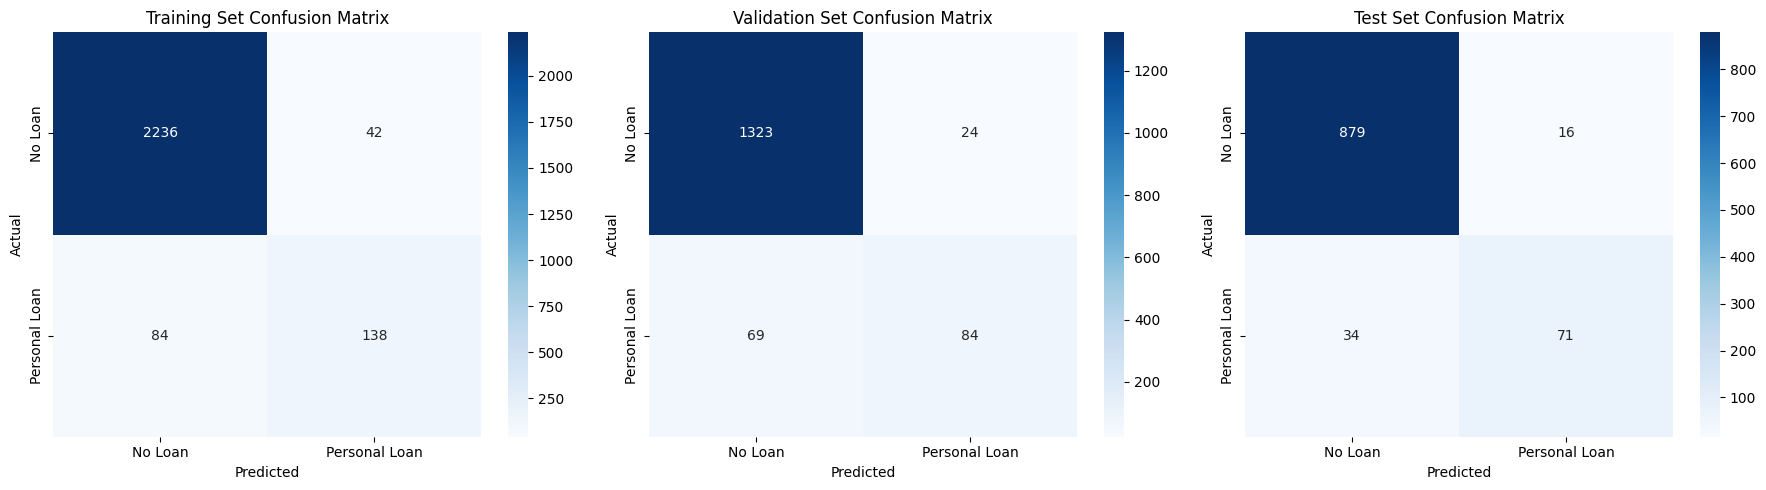

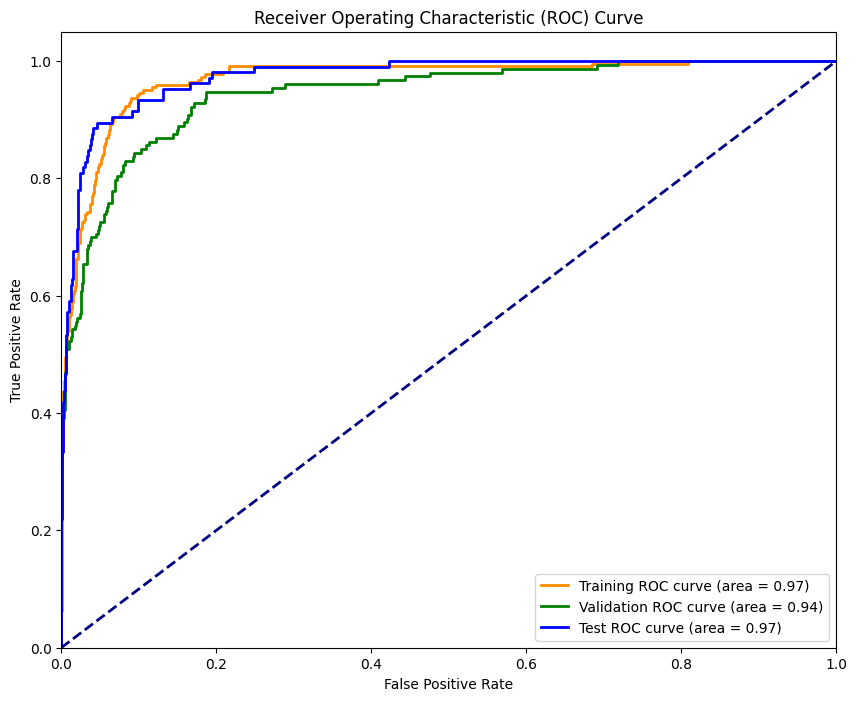

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the training, validation, and test sets
y_train_pred = lda_model.predict(X_train)
y_val_pred = lda_model.predict(X_val)
y_test_pred = lda_model.predict(X_test)

# Calculate confusion matrices
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
conf_matrix_val = confusion_matrix(y_val, y_val_pred)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

# Calculate accuracy scores
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_val = accuracy_score(y_val, y_val_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

# Print classification reports (includes precision, recall, f1-score, and support)
print("Training Set Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\nValidation Set Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred))


# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Loan', 'Personal Loan'])
axes[0].set_yticklabels(['No Loan', 'Personal Loan'])


sns.heatmap(conf_matrix_val, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Set Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Loan', 'Personal Loan'])
axes[1].set_yticklabels(['No Loan', 'Personal Loan'])


sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Set Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticklabels(['No Loan', 'Personal Loan'])
axes[2].set_yticklabels(['No Loan', 'Personal Loan'])

plt.tight_layout()
plt.show()


# Calculate ROC curves and AUC
y_train_prob = lda_model.predict_proba(X_train)[:, 1]
y_val_prob = lda_model.predict_proba(X_val)[:, 1]
y_test_prob = lda_model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_prob)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_val_prob)
roc_auc_val = auc(fpr_val, tpr_val)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='Training ROC curve (area = %0.2f)' % roc_auc_train)
plt.plot(fpr_val, tpr_val, color='green', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc_val)
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label='Test ROC curve (area = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

#Naive Bayes

Since most of the data in this dataset is continuous, we will build the Gaussian version of the model which doesn't require binning.

In [16]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model using the training data
gnb_model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


After fitting the model, let's check performance.

In [17]:
from sklearn.metrics import classification_report

# Make predictions on the training, validation, and test sets
y_train_pred_gnb = gnb_model.predict(X_train)
y_val_pred_gnb = gnb_model.predict(X_val)
y_test_pred_gnb = gnb_model.predict(X_test)

# Print the classification reports
print("Training Set Classification Report (Naive Bayes):")
print(classification_report(y_train, y_train_pred_gnb))

print("\nValidation Set Classification Report (Naive Bayes):")
print(classification_report(y_val, y_val_pred_gnb))

print("\nTest Set Classification Report (Naive Bayes):")
print(classification_report(y_test, y_test_pred_gnb))

Training Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      2278
           1       0.45      0.59      0.51       222

    accuracy                           0.90      2500
   macro avg       0.70      0.76      0.73      2500
weighted avg       0.91      0.90      0.90      2500


Validation Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1347
           1       0.49      0.55      0.52       153

    accuracy                           0.90      1500
   macro avg       0.72      0.74      0.73      1500
weighted avg       0.90      0.90      0.90      1500


Test Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       895
           1       0.55      0.60      0.57       105

    accuracy                    

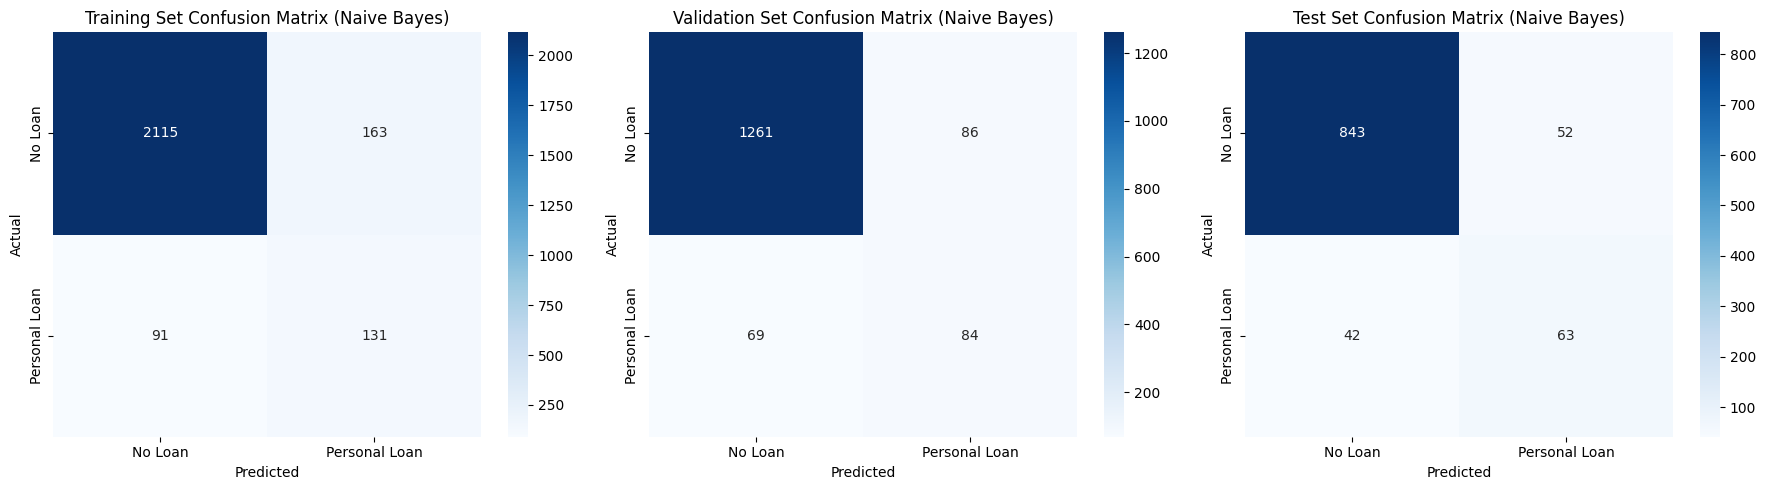

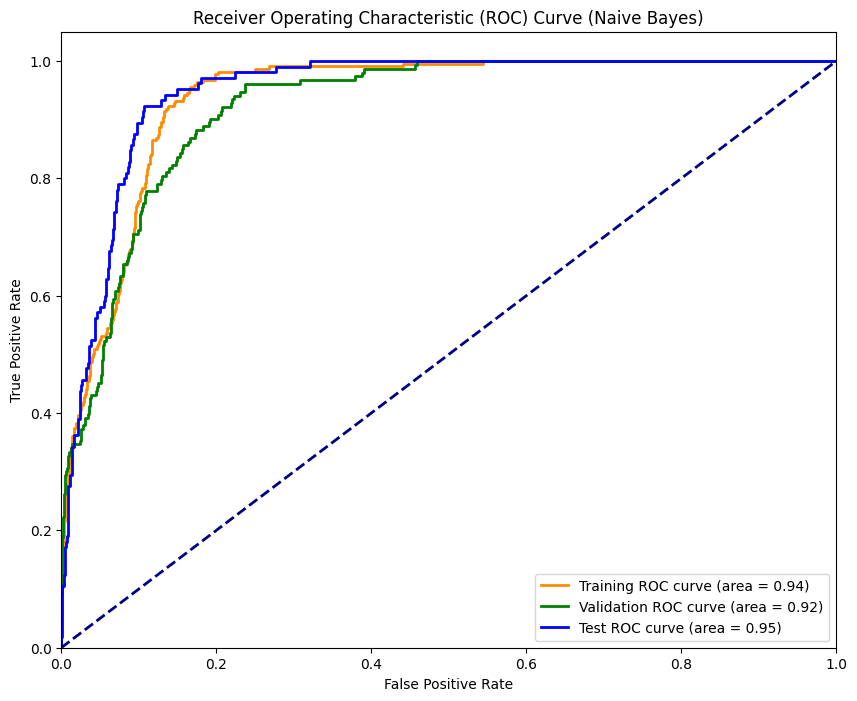

In [18]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions and get probabilities on the training, validation, and test sets
y_train_pred_gnb = gnb_model.predict(X_train)
y_val_pred_gnb = gnb_model.predict(X_val)
y_test_pred_gnb = gnb_model.predict(X_test)

y_train_prob_gnb = gnb_model.predict_proba(X_train)[:, 1]
y_val_prob_gnb = gnb_model.predict_proba(X_val)[:, 1]
y_test_prob_gnb = gnb_model.predict_proba(X_test)[:, 1]


# Calculate confusion matrices
conf_matrix_train_gnb = confusion_matrix(y_train, y_train_pred_gnb)
conf_matrix_val_gnb = confusion_matrix(y_val, y_val_pred_gnb)
conf_matrix_test_gnb = confusion_matrix(y_test, y_test_pred_gnb)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(conf_matrix_train_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix (Naive Bayes)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Loan', 'Personal Loan'])
axes[0].set_yticklabels(['No Loan', 'Personal Loan'])


sns.heatmap(conf_matrix_val_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Set Confusion Matrix (Naive Bayes)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Loan', 'Personal Loan'])
axes[1].set_yticklabels(['No Loan', 'Personal Loan'])


sns.heatmap(conf_matrix_test_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Set Confusion Matrix (Naive Bayes)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticklabels(['No Loan', 'Personal Loan'])
axes[2].set_yticklabels(['No Loan', 'Personal Loan'])

plt.tight_layout()
plt.show()


# Calculate ROC curves and AUC
fpr_train_gnb, tpr_train_gnb, thresholds_train_gnb = roc_curve(y_train, y_train_prob_gnb)
roc_auc_train_gnb = auc(fpr_train_gnb, tpr_train_gnb)

fpr_val_gnb, tpr_val_gnb, thresholds_val_gnb = roc_curve(y_val, y_val_prob_gnb)
roc_auc_val_gnb = auc(fpr_val_gnb, tpr_val_gnb)

fpr_test_gnb, tpr_test_gnb, thresholds_test_gnb = roc_curve(y_test, y_test_prob_gnb)
roc_auc_test_gnb = auc(fpr_test_gnb, tpr_test_gnb)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train_gnb, tpr_train_gnb, color='darkorange', lw=2, label='Training ROC curve (area = %0.2f)' % roc_auc_train_gnb)
plt.plot(fpr_val_gnb, tpr_val_gnb, color='green', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc_val_gnb)
plt.plot(fpr_test_gnb, tpr_test_gnb, color='blue', lw=2, label='Test ROC curve (area = %0.2f)' % roc_auc_test_gnb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Naive Bayes)')
plt.legend(loc="lower right")
plt.show()

Try binning the continuous variables and rerunning the model to see if performance changes.